In [ ]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 22.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']
#HEAD CHECK
# Archivo CSV
file_path = 'Valencia_2015_Otros.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.05911236 0.03055376 0.02819829 0.01625417 0.01605513
  0.02560449 0.01552975 0.01860892 0.05406791 0.02939916]
 [0.05911236 0.         0.03078275 0.03207533 0.07419767 0.06999335
  0.07196905 0.05578751 0.04474835 0.02164472 0.03336499]
 [0.03055376 0.03078275 0.         0.01318102 0.04498035 0.04126705
  0.04527083 0.02858622 0.02038324 0.03245112 0.01742627]
 [0.02819829 0.03207533 0.01318102 0.         0.04318388 0.03898548
  0.04311176 0.02611953 0.01704747 0.03232335 0.01381553]
 [0.01625417 0.07419767 0.04498035 0.04318388 0.         0.01063919
  0.02207771 0.02070799 0.03279132 0.06907686 0.04353329]
 [0.01605513 0.06999335 0.04126705 0.03898548 0.01063919 0.
  0.01706769 0.01788068 0.0288465  0.06479412 0.03901692]
 [0.02560449 0.07196905 0.04527083 0.04311176 0.02207771 0.01706769
  0.         0.02962206 0.03340466 0.06946617 0.04302453]
 [0.01552975 0.05578751 0.02858622 0.02611953 0.02070799 

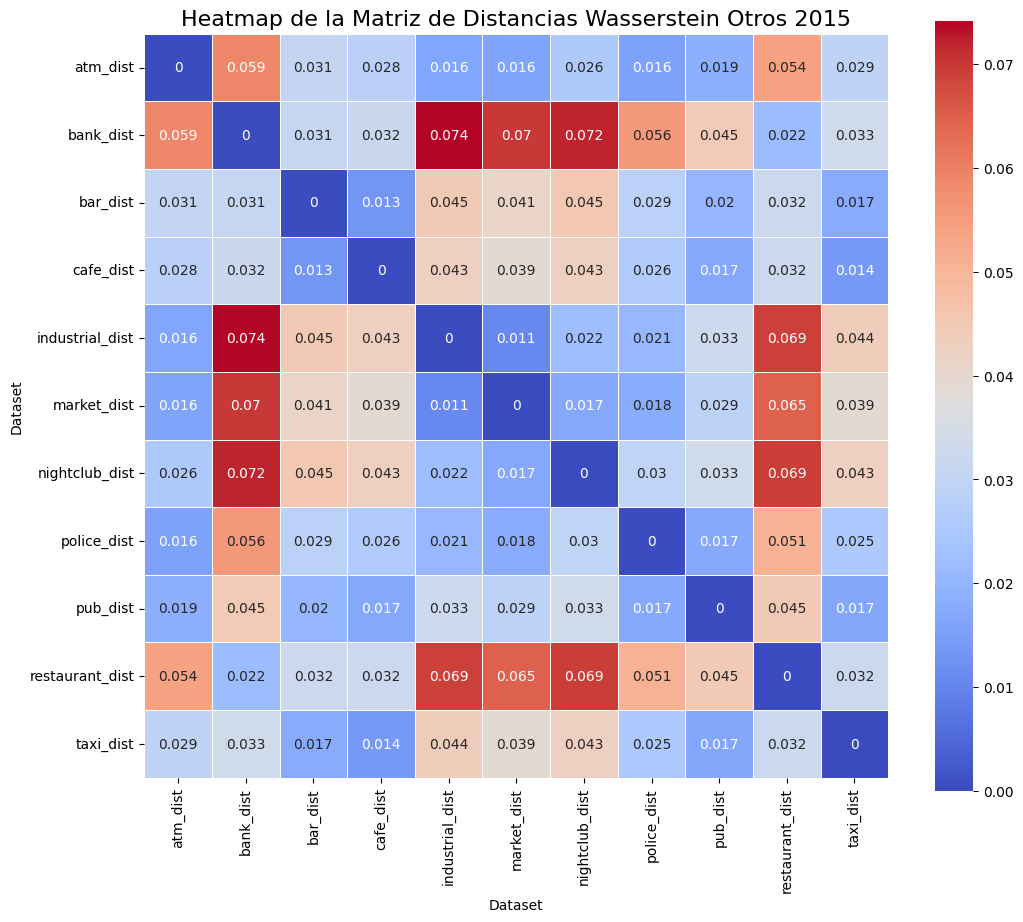

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.0, 0.05911236, 0.03055376, 0.02819829, 0.01625417, 0.01605513, 0.02560449, 0.01552975, 0.01860892, 0.05406791, 0.02939916],
    [0.05911236, 0.0, 0.03078275, 0.03207533, 0.07419767, 0.06999335, 0.07196905, 0.05578751, 0.04474835, 0.02164472, 0.03336499],
    [0.03055376, 0.03078275, 0.0, 0.01318102, 0.04498035, 0.04126705, 0.04527083, 0.02858622, 0.02038324, 0.03245112, 0.01742627],
    [0.02819829, 0.03207533, 0.01318102, 0.0, 0.04318388, 0.03898548, 0.04311176, 0.02611953, 0.01704747, 0.03232335, 0.01381553],
    [0.01625417, 0.07419767, 0.04498035, 0.04318388, 0.0, 0.01063919, 0.02207771, 0.02070799, 0.03279132, 0.06907686, 0.04353329],
    [0.01605513, 0.06999335, 0.04126705, 0.03898548, 0.01063919, 0.0, 0.01706769, 0.01788068, 0.0288465, 0.06479412, 0.03901692],
    [0.02560449, 0.07196905, 0.04527083, 0.04311176, 0.02207771, 0.01706769, 0.0, 0.02962206, 0.03340466, 0.06946617, 0.04302453],
    [0.01552975, 0.05578751, 0.02858622, 0.02611953, 0.02070799, 0.01788068, 0.02962206, 0.0, 0.01726653, 0.05097561, 0.02538951],
    [0.01860892, 0.04474835, 0.02038324, 0.01704747, 0.03279132, 0.0288465, 0.03340466, 0.01726653, 0.0, 0.04493774, 0.01669757],
    [0.05406791, 0.02164472, 0.03245112, 0.03232335, 0.06907686, 0.06479412, 0.06946617, 0.05097561, 0.04493774, 0.0, 0.03233454],
    [0.02939916, 0.03336499, 0.01742627, 0.01381553, 0.04353329, 0.03901692, 0.04302453, 0.02538951, 0.01669757, 0.03233454, 0.0]
])


# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein Otros 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015_Otros.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         1.79268479 0.5520671  0.99847436 0.23305279 0.18333375
  0.21411347 0.16969848 0.28231484 1.75101995 0.63435245]
 [1.79268479 0.         1.41714263 0.79421043 1.86247528 1.86247528
  1.86247528 1.68402863 1.63863897 0.6238054  1.15833235]
 [0.5520671  1.41714263 0.         0.6229322  0.73309141 0.62722445
  0.5533945  0.57577336 0.31847835 1.37547779 0.45883143]
 [0.99847436 0.79421043 0.6229322  0.         1.1102351  1.18180811
  1.09701455 0.88981819 0.84442854 1.25881195 0.38403153]
 [0.23305279 1.86247528 0.73309141 1.1102351  0.         0.19703883
  0.28021842 0.22138304 0.43322814 1.84164286 0.74611318]
 [0.18333375 1.86247528 0.62722445 1.18180811 0.19703883 0.
  0.22026598 0.29198992 0.37960291 1.84164286 0.8176862 ]
 [0.21411347 1.86247528 0.5533945  1.09701455 0.28021842 0.22026598
  0.         0.20719635 0.33751273 1.84164286 0.73289263]
 [0.16969848 1.68402863 0.57577336 0.88981819 0.22138304 0.29

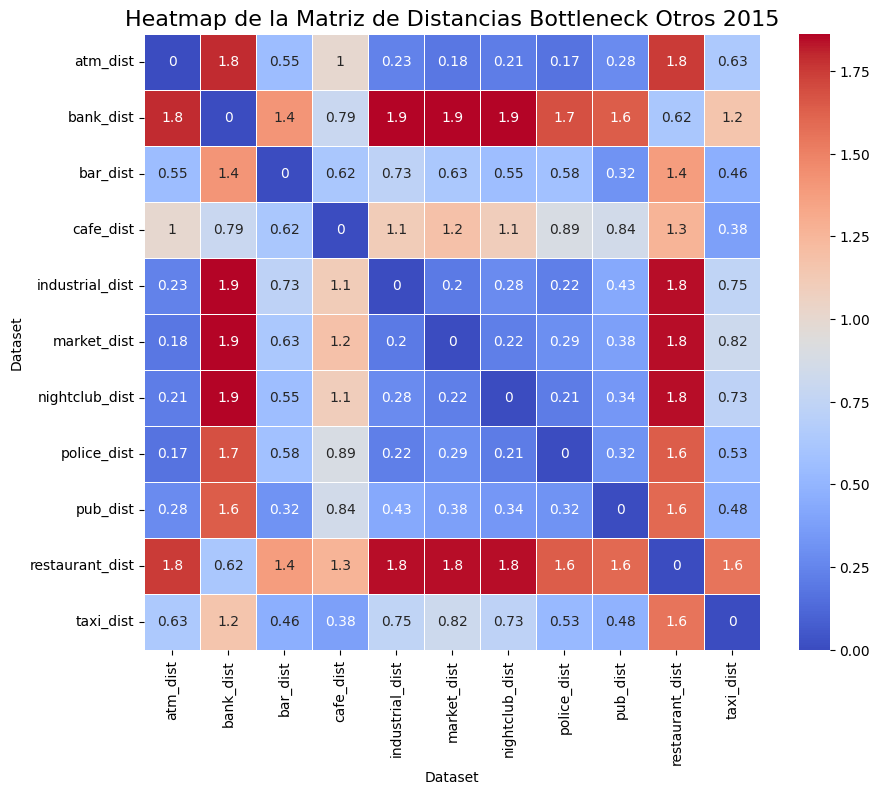

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.0, 1.79268479, 0.5520671, 0.99847436, 0.23305279, 0.18333375, 0.21411347, 0.16969848, 0.28231484, 1.75101995, 0.63435245],
    [1.79268479, 0.0, 1.41714263, 0.79421043, 1.86247528, 1.86247528, 1.86247528, 1.68402863, 1.63863897, 0.6238054, 1.15833235],
    [0.5520671, 1.41714263, 0.0, 0.6229322, 0.73309141, 0.62722445, 0.5533945, 0.57577336, 0.31847835, 1.37547779, 0.45883143],
    [0.99847436, 0.79421043, 0.6229322, 0.0, 1.1102351, 1.18180811, 1.09701455, 0.88981819, 0.84442854, 1.25881195, 0.38403153],
    [0.23305279, 1.86247528, 0.73309141, 1.1102351, 0.0, 0.19703883, 0.28021842, 0.22138304, 0.43322814, 1.84164286, 0.74611318],
    [0.18333375, 1.86247528, 0.62722445, 1.18180811, 0.19703883, 0.0, 0.22026598, 0.29198992, 0.37960291, 1.84164286, 0.8176862],
    [0.21411347, 1.86247528, 0.5533945, 1.09701455, 0.28021842, 0.22026598, 0.0, 0.20719635, 0.33751273, 1.84164286, 0.73289263],
    [0.16969848, 1.68402863, 0.57577336, 0.88981819, 0.22138304, 0.29198992, 0.20719635, 0.0, 0.31934416, 1.64236379, 0.52569628],
    [0.28231484, 1.63863897, 0.31847835, 0.84442854, 0.43322814, 0.37960291, 0.33751273, 0.31934416, 0.0, 1.59697413, 0.48030663],
    [1.75101995, 0.6238054, 1.37547779, 1.25881195, 1.84164286, 1.84164286, 1.84164286, 1.64236379, 1.59697413, 0.0, 1.55283701],
    [0.63435245, 1.15833235, 0.45883143, 0.38403153, 0.74611318, 0.8176862, 0.73289263, 0.52569628, 0.48030663, 1.55283701, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck Otros 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
